# Coursework Template

**Dependencies and imports**

This can take a minute...

In [1]:
!pip install swig
!pip install --upgrade rldurham
!pip install pillow==10.0.0

Requirement already up-to-date: rldurham in /home2/grkp39/myjupyterenv/lib/python3.9/site-packages (0.0.5)


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import rldurham as rld

**Reinforcement learning agent**

Replace this with your own agent, I recommend starting with TD3 (lecture 8).

In [3]:
# Device configuration
device = torch.device("cpu")  # Set to GPU if available


# Hyperparameters
GAMMA = 0.99
TAU = 0.01
POLICY_NOISE = 0.2
NOISE_CLIP = 0.5
ACTOR_LR = 3e-4
CRITIC_LR = 3e-4
BATCH_SIZE = 64
MAX_BUFFER_SIZE = int(1e6)
START_STEPS = 20000
EXPLORATION_NOISE = 0.2


# Replay Buffer
class ReplayBuffer:
    def __init__(self, state_dim, action_dim, max_size=MAX_BUFFER_SIZE):
        self.max_size = max_size
        self.size = 0
        self.ptr = 0
        self.state = np.zeros((max_size, state_dim))
        self.action = np.zeros((max_size, action_dim))
        self.reward = np.zeros((max_size, 1))
        self.next_state = np.zeros((max_size, state_dim))
        self.not_done = np.zeros((max_size, 1))

    def __len__(self):
        return self.size

    def add(self, state, action, reward, next_state, done):
        index = self.ptr % self.max_size
        self.state[index] = state
        self.action[index] = action
        self.reward[index] = reward
        self.next_state[index] = next_state
        self.not_done[index] = 1.0 - done
        self.ptr += 1
        self.size = min(self.size + 1, self.max_size)

    def sample(self, batch_size):
        indices = np.random.randint(0, self.size, size=batch_size)
        return (
            torch.FloatTensor(self.state[indices]).to(device),
            torch.FloatTensor(self.next_state[indices]).to(device),
            torch.FloatTensor(self.action[indices]).to(device),
            torch.FloatTensor(self.reward[indices]).to(device),
            torch.FloatTensor(self.not_done[indices]).to(device)
        )


# Actor Network
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, max_action):
        super(Actor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim),
            nn.Tanh()
        )
        self.max_action = max_action

    def forward(self, state):
        return self.max_action * self.net(state)


# Critic Network
class Critic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(Critic, self).__init__()
        self.q1 = nn.Sequential(
            nn.Linear(state_dim + action_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
        self.q2 = nn.Sequential(
            nn.Linear(state_dim + action_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    def forward(self, state, action):
        state_action = torch.cat([state, action], dim=1)
        return self.q1(state_action), self.q2(state_action)

    
# TD3 Agent
class TD3Agent:
    def __init__(self, state_dim, action_dim, max_action):
        self.actor = Actor(state_dim, action_dim, max_action).to(device)
        self.actor_target = Actor(state_dim, action_dim, max_action).to(device)
        self.actor_target.load_state_dict(self.actor.state_dict())
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=ACTOR_LR)

        self.critic = Critic(state_dim, action_dim).to(device)
        self.critic_target = Critic(state_dim, action_dim).to(device)
        self.critic_target.load_state_dict(self.critic.state_dict())
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=CRITIC_LR)

        self.replay_buffer = ReplayBuffer(state_dim, action_dim)
        self.max_action = max_action

        self.update_count = 0

    def select_action(self, state):
        state = torch.FloatTensor(state.reshape(1, -1)).to(device)
        return self.actor(state).cpu().data.numpy().flatten()

    def update(self, batch_size):
        self.update_count += 1
        state, next_state, action, reward, not_done = self.replay_buffer.sample(batch_size)

    # Critic Update
        with torch.no_grad():
            noise = torch.randn_like(action) * POLICY_NOISE
            noise = noise.clamp(-NOISE_CLIP, NOISE_CLIP)
            next_action = (self.actor_target(next_state) + noise).clamp(-self.max_action, self.max_action)
            target_q1, target_q2 = self.critic_target(next_state, next_action)
            target_q = reward + not_done * GAMMA * torch.min(target_q1, target_q2)

        current_q1, current_q2 = self.critic(state, action)
        critic_loss = nn.MSELoss()(current_q1, target_q) + nn.MSELoss()(current_q2, target_q)

        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

    # Delayed policy update
        if self.update_count % 2 == 0:
            action = self.actor(state)
            q1, _ = self.critic(state, action)
            actor_loss = -q1.mean()

            self.actor_optimizer.zero_grad()
            actor_loss.backward()
            self.actor_optimizer.step()

            for param, target_param in zip(self.actor.parameters(), self.actor_target.parameters()):
                target_param.data.copy_(TAU * param.data + (1.0 - TAU) * target_param.data)
            for param, target_param in zip(self.critic.parameters(), self.critic_target.parameters()):
                target_param.data.copy_(TAU * param.data + (1.0 - TAU) * target_param.data)

**Prepare the environment and wrap it to capture statistics, logs, and videos**

The device is: cpu (as recommended)
actions are continuous with 4 dimensions/#actions
observations are continuous with 24 dimensions/#observations
maximum timesteps is: None


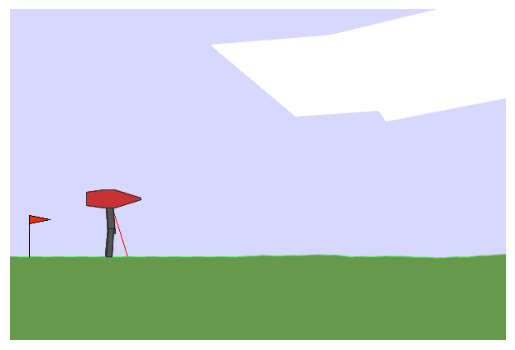

In [4]:
env = rld.make("rldurham/Walker", render_mode="rgb_array")
# env = rld.make("rldurham/Walker", render_mode="rgb_array", hardcore=True) # only attempt this when your agent has solved the non-hardcore version

# get statistics, logs, and videos
env = rld.Recorder(
    env,
    smoothing=10,             # track rolling averages (useful for plotting)
    video=True,              # enable recording videos
    video_folder="videos",        # folder for videos
    video_prefix="gkrp39-agent-video",  # prefix for videos (replace xxxx00 with your username)
    logs=True,              # keep logs
)

# training on CPU recommended
rld.check_device()

# environment info
discrete_act, discrete_obs, act_dim, obs_dim = rld.env_info(env, print_out=True)

# render start image
env.reset(seed=42)
rld.render(env)

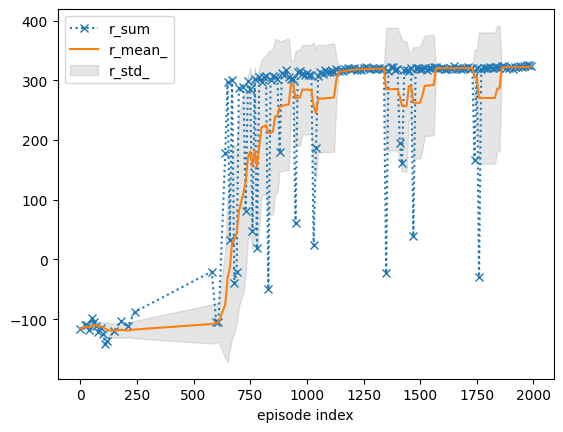

In [5]:
# in the submission please use seed_everything with seed 42 for verification
seed, observation, info = rld.seed_everything(42, env)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
max_action = float(env.action_space.high[0])

# initialise agent
agent = TD3Agent(state_dim, action_dim, max_action)
max_episodes = 2000
max_timesteps = 2000

# track statistics for plotting
tracker = rld.InfoTracker()

# switch video recording off (only switch on every x episodes as this is slow)
env.video = True

episode_rewards = []
total_steps = 0 

# training procedure
for episode in range(max_episodes):

    # recording statistics and video can be switched on and off (video recording is slow!)
    env.info = episode % 10 == 0   # track every x episodes (usually tracking every episode is fine)
    env.video = episode % 10 == 0  # record videos every x episodes (set BEFORE calling reset!)

    # reset for new episode
    observation, info = env.reset()
    episode_reward = 0.0

    # run episode
    for t in range(max_timesteps):
        # 初始随机探索
        if total_steps < START_STEPS:
            action = env.action_space.sample()
        else:
            # 执行策略 + 额外探索噪声
            action = agent.select_action(observation)
            noise = np.random.normal(0, EXPLORATION_NOISE * max_action, size=action.shape)
            action = np.clip(action + noise, -max_action, max_action)
        
        # take action in the environment
        next_observation, reward, terminated, truncated, info = env.step(action)
        # check whether done
        done = terminated or truncated

        # remember
        agent.replay_buffer.add(observation, action, reward, next_observation, done)

        # TRAIN THE AGENT HERE!
        if len(agent.replay_buffer) > BATCH_SIZE:
            agent.update(BATCH_SIZE)

        # 更新当前状态
        episode_reward += reward
        observation = next_observation
        total_steps += 1

        # stop episode
        if done:
            break

    # track and plot statistics
    tracker.track(info)
    if (episode + 1) % 10 == 0:
        tracker.plot(r_mean_=True, r_std_=True, r_sum=dict(linestyle=':', marker='x'))

# don't forget to close environment (e.g. triggers last video save)
env.close()

# write log file (for coursework)
env.write_log(folder="logs", file="grkp39-agent-log.txt")  # replace xxxx00 with your username

A small demo with a predefined heuristic that is suboptimal and has no notion of balance (and is designed for the orignal BipedalWalker environment)...

In [6]:
from gymnasium.envs.box2d.bipedal_walker import BipedalWalkerHeuristics

env = rld.make(
    "rldurham/Walker",
    # "BipedalWalker-v3",
    render_mode="human",
    # render_mode="rgb_array",
    hardcore=False,
    # hardcore=True,
)
_, obs, info = rld.seed_everything(42, env)

heuristics = BipedalWalkerHeuristics()

act = heuristics.step_heuristic(obs)
for _ in range(500):
    obs, rew, terminated, truncated, info = env.step(act)
    act = heuristics.step_heuristic(obs)
    if terminated or truncated:
        break
    if env.render_mode == "rgb_array":
        rld.render(env, clear=True)
env.close()

[rank: 0] Seed set to 42
